https://drive.google.com/file/d/11wp4Bm-hEVwmZq8GmqbLpKpJiqvDSNAe/view?usp=sharing --- тут лежит датасет который мы будем использовать. \
Мы хотим обучить наш unet на небольшом датасете. Нужно заполнить репорт и сделать выводы. Чтобы успеть сделать много экспериментов нужна видеокарта. Можно использовать colab, тут есть бесплатные gpu ресурсы --- так будет быстрее.

  * Сделать train/test split (или кросс-валидацию), зафиксировать все сиды, чтобы более-менее воспроизводились результаты. Добавить метрику jaccard index. Переобучиться на одном батче (например, 4 картинки), попробовать получить почти идеальное качество, посмотреть, получилось или нет. Посчитать метрики для батча и для теста. Обучить на всем train, построить train/val кривые для loss и для jaccard index, подобрать оптимальное время обучения (количество шагов) для фиксированных параметров. Визуализировать topN самых плохих предсказаний.
  * Попробовать улучшить качество не меняя архитектуру: аугментации, гиперпараметры. Сделать test time аугментации через horizontal flip, посмотреть улучшается ли что-то.
  * Попробовать улучшить качество изменяя архитектуру.
 * (+2 балла) Сделать train/test разбиение. Внутри train сделать 5fold, обучить 5 моделей. Построить кривые обучения для каждого фолда. Предсказать тест со всех 5 моделей и сагрегировать предсказания (до расчета метрик), сравнить с одной моделью обученной на всех данных. Сравнить с моделями обученными на фолдах. Сравнить плохие предсказания теста на разных фолдах. Ошибается на одних и тех же семплах или на разных?
 * (+3 балла) Сделать unet с pretrained энкодером (можно взять vgg или resnet18/34), сравнить с предыдущими пунктами.

In [ ]:
device = "cuda"

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


##Датасет

In [ ]:
!pip install -q gdown

In [ ]:
!gdown 11wp4Bm-hEVwmZq8GmqbLpKpJiqvDSNAe -O dataset.zip

Downloading...
From (original): https://drive.google.com/uc?id=11wp4Bm-hEVwmZq8GmqbLpKpJiqvDSNAe
From (redirected): https://drive.google.com/uc?id=11wp4Bm-hEVwmZq8GmqbLpKpJiqvDSNAe&confirm=t&uuid=bc1f3d0a-a263-4307-a501-cf674bb9eee1
To: /content/dataset.zip
100% 154M/154M [00:03<00:00, 44.8MB/s]


In [93]:
!unzip dataset.zip -d /content/dataset

In [ ]:
import os

for root, dirs, files in os.walk('/content/dataset'):
    print(root)
    print(files[:5])
    print('---')

/content/dataset
[]
---
/content/dataset/dataset
[]
---
/content/dataset/dataset/masks
['1803271743-00000327.png', '1803260054-00000076.png', '1803290444-00000528.png', '1803262023-00000569.png', '1803250018-00000427.png']
---
/content/dataset/dataset/images
['1803280908-00000049.jpg', '1803242010-00000066.jpg', '1803250018-00000113.jpg', '1803261336-00000041.jpg', '1803252014-00000510.jpg']
---


In [ ]:
import os
import random
import numpy as np
from glob import glob

import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.transforms import functional
from torchvision import io
import torchvision.transforms as transforms
from torch import nn


###Фиксируем сиды

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
image_paths = sorted(glob('/content/dataset/dataset/images/*'))
mask_paths = sorted(glob('/content/dataset/dataset/masks/*'))

print(len(image_paths))
print(len(mask_paths))

2000
2000


###Проверяем картинку и маску

(800, 600, 3)
(800, 600)


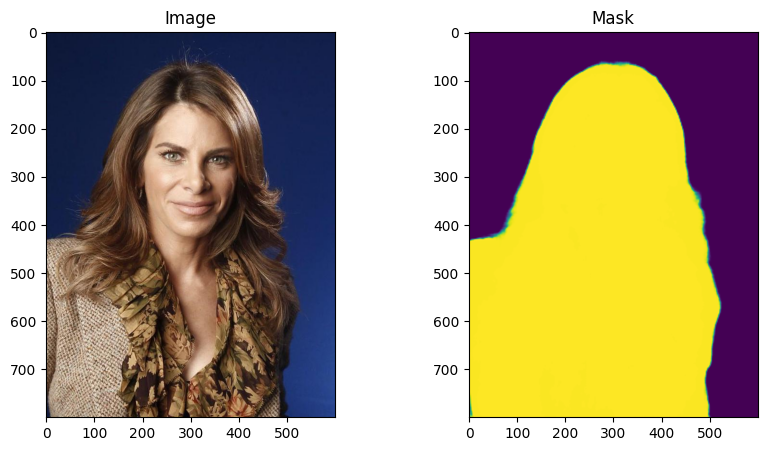

In [ ]:
idx = 0

image = cv2.imread(image_paths[idx])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_paths[idx], 0)

print(image.shape)
print(mask.shape)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title('Image')

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title('Mask')

plt.show()

In [ ]:
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.2,
    random_state=SEED
)

print('Train:', len(train_imgs))
print('Val:', len(val_imgs))

Train: 1600
Val: 400


In [ ]:
image_prepare = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
])

class SegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, images, masks, transform=image_prepare):
        self.images = images
        self.masks = masks

        assert len(self.images) == len(self.masks)

        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, item):
        img = self.transform(io.read_image(str(self.images[item])))
        mask = self.transform(io.read_image(str(self.masks[item])))
        return img, mask

In [44]:
train_dataset = SegmentationDataset(
    train_imgs,
    train_masks
)

val_dataset = SegmentationDataset(
    val_imgs,
    val_masks
)

###Построение UNET

In [ ]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=0):
        super(CNNBlock, self).__init__()

        self.seq_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True))

    def forward(self, x):
        return self.seq_block(x)

class CNNBlocks(nn.Module):
    def __init__(self, n_conv, in_channels, out_channels, padding):
          super(CNNBlocks, self).__init__()

          self.layers = nn.ModuleList()
          for _ in range(n_conv):
              self.layers.append(CNNBlock(in_channels, out_channels, padding=padding))
              in_channels = out_channels

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels, padding, n_down=4):
        super(Encoder, self).__init__()

        self.enc_layers = nn.ModuleList()
        for _ in range(n_down):
            self.enc_layers += [CNNBlocks(n_conv=2,
                                          in_channels=in_channels,
                                          out_channels=out_channels,
                                          padding=padding),
                                nn.MaxPool2d(2, 2)
                                ]

            in_channels = out_channels
            out_channels = 2 * out_channels

        self.enc_layers.append(CNNBlocks(n_conv=2,
                                         in_channels=in_channels,
                                         out_channels=out_channels,
                                         padding=padding
                                         ))

    def forward(self, x):
        connections = []
        for layer in self.enc_layers:
            if isinstance(layer, CNNBlocks):
                x = layer(x)
                connections.append(x)
            else:
                x = layer(x)
        return x, connections

class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels, exit_channels, padding, n_up=4):
        super(Decoder, self).__init__()

        self.exit_channels = exit_channels
        self.layers = nn.ModuleList()

        for i in range(n_up):
            self.layers += [nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
                            CNNBlocks(n_conv=2, in_channels=in_channels, out_channels=out_channels, padding=padding)]

            in_channels //= 2
            out_channels //= 2

        self.layers.append(nn.Conv2d(in_channels, self.exit_channels, kernel_size=1, padding=0))

    def forward(self, x, connections):
        connections.pop(-1)
        for layer in self.layers:
            if isinstance(layer, CNNBlocks):
                connections_current = connections.pop(-1)
                dim_4 = connections_current.size(3) - x.size(3)
                dim_3 = connections_current.size(2) - x.size(2)
                if dim_4 != 0 or dim_3 != 0:
                    x = nn.functional.pad(x, [0, dim_4, 0, dim_3])
                x = torch.cat([x, connections_current], dim=1)
                x = layer(x)
            else:
                x = layer(x)
        return x

class UNET(nn.Module):
    def __init__(self, in_channels, first_out_channels, exit_channels, n_down=4, padding=1):
        super(UNET, self).__init__()
        self.encoder = Encoder(in_channels, first_out_channels, padding=padding, n_down=n_down)
        self.decoder = Decoder(first_out_channels * (2 ** n_down),
                               first_out_channels * (2 ** (n_down - 1)),
                               exit_channels, padding=padding, n_up=n_down)

    def forward(self, x):
        enc_out, connections = self.encoder(x)
        return self.decoder(enc_out, connections)

##Обучение

In [51]:
import torchmetrics

jaccard = torchmetrics.classification.BinaryJaccardIndex().to(device)
def jaccard_metric(pred, y):
    return jaccard(pred, y > jaccard.threshold)

##Переобучение на одном батче

In [49]:
overfit_batch = next(iter(DataLoader(train_dataset, batch_size=4, shuffle=False)))
images, masks = overfit_batch
images, masks = images.to(device), masks.to(device)

model = UNET(in_channels=3, first_out_channels=16, exit_channels=1).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
from tqdm.auto import tqdm

In [85]:
import matplotlib.pyplot as plt

def train(loader):
    model.train()
    train_losses = []
    train_iou = []
    for img_batch, mask_batch in tqdm(loader):
          img_batch, mask_batch = img_batch.to(device), mask_batch.to(device)
          pred = model(img_batch)
          loss = criterion(pred, mask_batch)

          iou = jaccard_metric(pred, mask_batch)
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          train_losses.append(loss.item())
          train_iou.append(iou.item())
    avg_train_loss = np.mean(train_losses)
    avg_train_iou = np.mean(train_iou)
    return avg_train_loss, avg_train_iou

In [86]:
def val(loader):
  model.eval()
  val_losses = []
  val_iou = []
  with torch.no_grad():
        for img_batch, mask_batch in tqdm(loader):
            img_batch, mask_batch = img_batch.to(device), mask_batch.to(device)
            pred = model(img_batch)
            loss = criterion(pred, mask_batch)
            iou = jaccard_metric(pred, mask_batch)

            val_losses.append(loss.item())
            val_iou.append(iou.item())
        avg_val_loss = np.mean(val_losses)
        avg_val_iou = np.mean(val_iou)
        return avg_val_loss, avg_val_iou

In [77]:
batch_size = 4

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(train_dataset, range(batch_size)),
    batch_size=batch_size,
)
val_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(val_dataset, range(batch_size)),
    batch_size=batch_size,
)

for epoch in range(50):
  loss, iou = train(train_loader)
  print(f"Epoch [{epoch+1}/50], Loss: {loss.item():.4f}, Jaccard: {iou.item():.4f}")
print("Переобучение завершено.")

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch [1/50], Loss: 0.0727, Jaccard: 0.9954


  0%|          | 0/1 [00:00<?, ?it/s]

Epoch [2/50], Loss: 0.0722, Jaccard: 0.9954


  0%|          | 0/1 [00:00<?, ?it/s]

...

Epoch [48/50], Loss: 0.0554, Jaccard: 0.9968


  0%|          | 0/1 [00:00<?, ?it/s]

Epoch [49/50], Loss: 0.0551, Jaccard: 0.9968


  0%|          | 0/1 [00:00<?, ?it/s]

Epoch [50/50], Loss: 0.0548, Jaccard: 0.9968
Переобучение завершено.


In [84]:
def calculate_final_metrics(model, batch_data, val_loader, metric, device):
    model.eval()
    images_b, masks_b = batch_data
    images_b, masks_b = images_b.to(device), masks_b.to(device)

    # 1. Метрики для переобученного батча
    with torch.no_grad():
        out_b = model(images_b)
        batch_loss = criterion(out_b, masks_b).item()
        batch_iou = metric(torch.sigmoid(out_b), masks_b.int()).item()

    # 2. Метрики для всего теста
    avg_test_loss, avg_test_iou = val(val_loader)

    print("-" * 30)
    print(f"OVERFIT BATCH: Loss = {batch_loss:.6f}, Jaccard = {batch_iou:.4f}")
    print(f"TEST SET:      Loss = {avg_test_loss:.6f}, Jaccard = {avg_test_iou:.4f}")
    print("-" * 30)

calculate_final_metrics(model, overfit_batch, val_loader, jaccard_metric, device)

  0%|          | 0/1 [00:00<?, ?it/s]

------------------------------
OVERFIT BATCH: Loss = 0.055325, Jaccard = 0.7114
TEST SET:      Loss = 1.527729, Jaccard = 0.3554
------------------------------


Видим, что на батче получилось пости идеальное качество, а на тесте все очень плохо

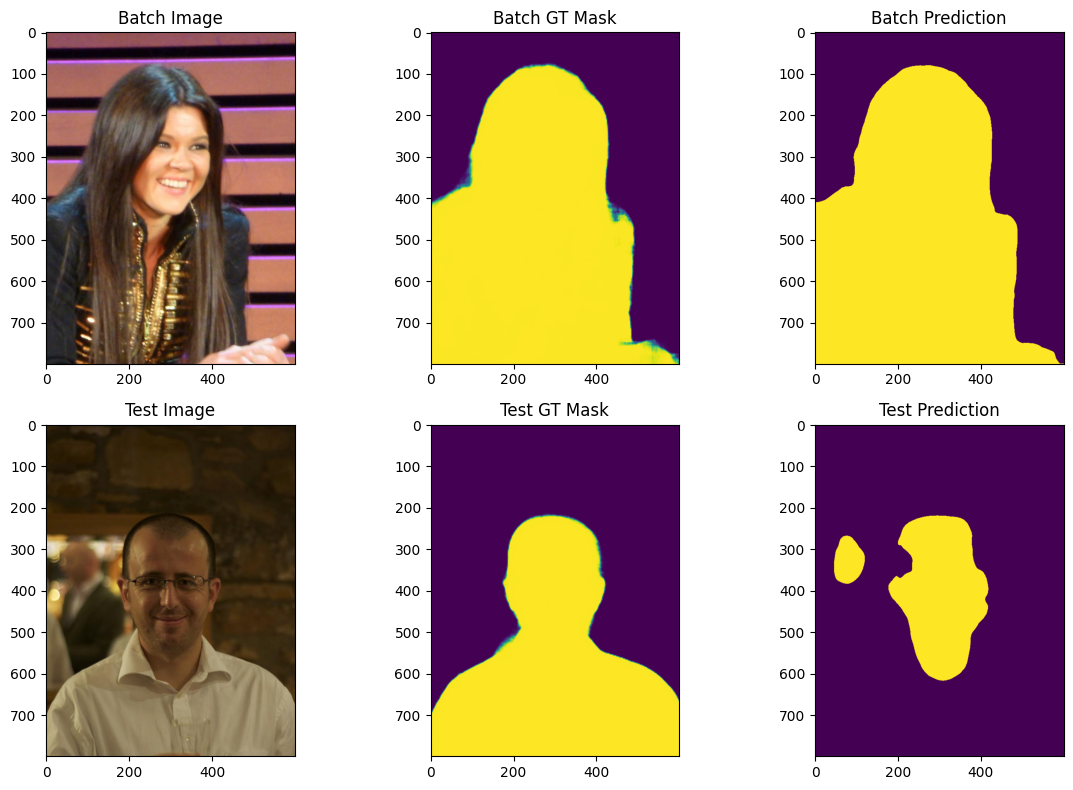

In [75]:
import matplotlib.pyplot as plt

def visualize_results(model, batch_data, val_dataset, device):
    model.eval()
    imgs_b, msks_b = batch_data
    test_img, test_mask = val_dataset[0]

    with torch.no_grad():
        pred_b = torch.sigmoid(model(imgs_b.to(device))).cpu()
        pred_t = torch.sigmoid(model(test_img.unsqueeze(0).to(device))).cpu()

    fig, axs = plt.subplots(2, 3, figsize=(12, 8))

    # Визуализация для батча
    axs[0, 0].imshow(imgs_b[0].permute(1, 2, 0).cpu().numpy())
    axs[0, 0].set_title("Batch Image")
    axs[0, 1].imshow(msks_b[0].squeeze().cpu().numpy())
    axs[0, 1].set_title("Batch GT Mask")
    axs[0, 2].imshow(pred_b[0].squeeze().cpu().numpy() > 0.5)
    axs[0, 2].set_title("Batch Prediction")

    # Визуализация для тестового изображения
    axs[1, 0].imshow(test_img.permute(1, 2, 0).cpu().numpy())
    axs[1, 0].set_title("Test Image")
    axs[1, 1].imshow(test_mask.squeeze().cpu().numpy())
    axs[1, 1].set_title("Test GT Mask")
    axs[1, 2].imshow(pred_t[0].squeeze().cpu().numpy() > 0.5)
    axs[1, 2].set_title("Test Prediction")

    plt.tight_layout()
    plt.show()

visualize_results(model, overfit_batch, val_dataset, device)

На Test Prediction случайные пятна, то есть модель выучила 4 картинки, а остальные сегментировать не может

###Обучимся на всем датасете

In [89]:
batch_size = 4

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

In [90]:
num_epochs = 25
history = {
    'train_loss': [], 'val_loss': [],
    'train_jaccard': [], 'val_jaccard': []
}
for epoch in range(num_epochs):
    avg_train_loss, avg_train_iou = train(train_loader)
    avg_val_loss, avg_val_iou = val(val_loader)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_jaccard'].append(avg_train_iou)
    history['val_jaccard'].append(avg_val_iou)

    print(f"Epoch {epoch+1:02d}: Loss(T/V): {avg_train_loss:.4f}/{avg_val_loss:.4f} | Jaccard(T/V): {avg_train_iou:.4f}/{avg_val_iou:.4f}")

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 01: Loss(T/V): 0.6079/0.5710 | Jaccard(T/V): 0.5402/0.5912


  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 24: Loss(T/V): 0.1145/0.1511 | Jaccard(T/V): 0.9194/0.8903


  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 25: Loss(T/V): 0.1103/0.1322 | Jaccard(T/V): 0.9227/0.9042


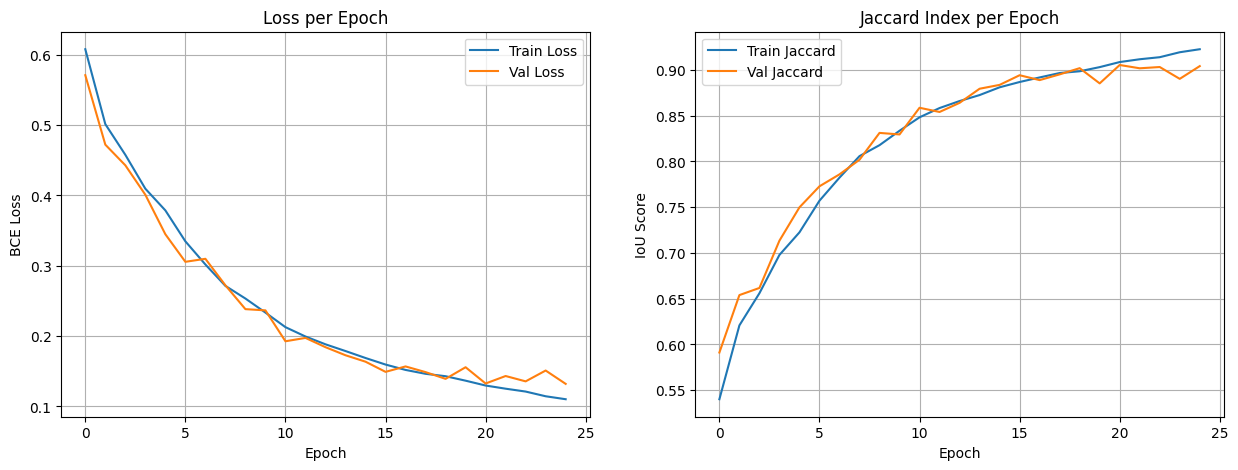

In [92]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_jaccard'], label='Train Jaccard')
plt.plot(history['val_jaccard'], label='Val Jaccard')
plt.title('Jaccard Index per Epoch')
plt.xlabel('Epoch')
plt.ylabel('IoU Score')
plt.grid(True)
plt.legend()

plt.show()